In [3]:
import pandas as pd

# Load processed dataset
df = pd.read_csv("../data/processed_energy_hourly.csv")

# Check columns
df.head()

,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,month,is_weekend,sin_hour,cos_hour
0,2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,12,1,-0.965926,-2.588190e-01
1,2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,12,1,-1.000000,-1.836970e-16
2,2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,12,1,-0.965926,2.588190e-01
3,2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,12,1,-0.866025,5.000000e-01
4,2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,12,1,-0.707107,7.071068e-01


In [4]:
power = df["Global_active_power"]

mean_val = power.mean()
median_val = power.median()
mode_val = power.mode()[0]
min_val = power.min()
max_val = power.max()
std_val = power.std()

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)
print("Min:", min_val)
print("Max:", max_val)
print("Std Dev:", std_val)

Mean: 1.0862004651446668
Median: 0.7995333333333333
Mode: 0.906
Min: 0.124
Max: 6.560533333333334
Std Dev: 0.8949415529266338


In [5]:
summary_table = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode", "Minimum", "Maximum", "Standard Deviation"],
    "Value": [
        mean_val,
        median_val,
        mode_val,
        min_val,
        max_val,
        std_val
    ]
})

summary_table

,Statistic,Value
0,Mean,1.086200
1,Median,0.799533
2,Mode,0.906000
3,Minimum,0.124000
4,Maximum,6.560533
5,Standard Deviation,0.894942


In [6]:
# Create readable labels
df["day_type"] = df["is_weekend"].map({0: "Weekday", 1: "Weekend"})

# Compute average consumption
week_comparison = df.groupby("day_type")["Global_active_power"].mean().reset_index()

week_comparison

,day_type,Global_active_power
0,Weekday,1.033863
1,Weekend,1.217259


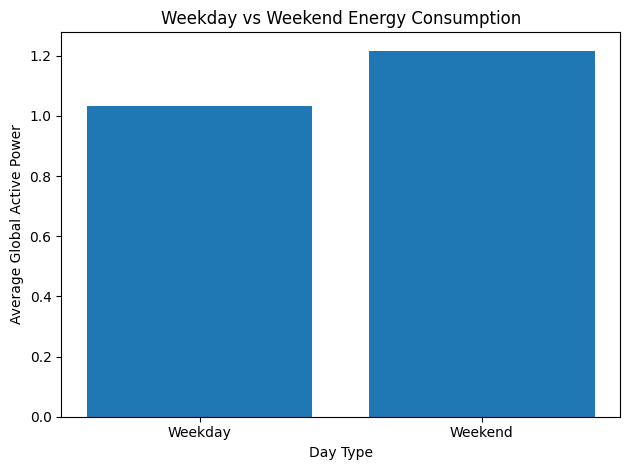

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(week_comparison["day_type"], week_comparison["Global_active_power"])
plt.title("Weekday vs Weekend Energy Consumption")
plt.xlabel("Day Type")
plt.ylabel("Average Global Active Power")
plt.tight_layout()
plt.savefig("figure4_weekday_vs_weekend.png")
plt.show()